In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

deg2rad = np.pi / 180.0
rad2deg = 180.0 / np.pi

R = 6.96e8
dt = 0.001
alpha = 6.048e13
dphi = 0.5*deg2rad
dtheta1_d = 1
dtheta2_d = 1
dtheta3_d = 0.5
tot_time = 365 * 11
N_steps = int(tot_time / dt)
save = 2000
N_save = int(N_steps / save)+1
N_phi = int(2*np.pi/ dphi)
v_mer_max = 1.296e6
omega_max_deg = 13.38
omega_max = omega_max_deg*deg2rad

theta_north = np.concatenate((
    np.arange(5, 30, dtheta1_d),
    np.arange(30, 60, dtheta2_d),
    np.arange(60, 90 + dtheta3_d, dtheta3_d)
))

theta_south = 180.0 - theta_north[:-1][::-1]  # mirror, no duplicate equator

theta_deg = np.concatenate((theta_north, theta_south))


# print("theta_1n:", theta_1n.shape)
# print("theta_2n:", theta_2n.shape)  
# print("theta_3:", theta_3.shape)
# print("theta_2s:", theta_2s.shape)
# print("theta_1s:", theta_1s.shape)

N_theta = (len(theta_north) + len(theta_south))
print("theta_north:", len(theta_north))
print("theta_south:", len(theta_south))
#theta_deg = np.concatenate((theta_1n, theta_2n, theta_3, theta_2s, theta_1s))

theta = theta_deg * deg2rad
dtheta1 = dtheta1_d * deg2rad
dtheta2 = dtheta2_d * deg2rad
dtheta3 = dtheta3_d * deg2rad

delta_x = R*np.min(np.sin(theta))*dphi
delta_y = R*dtheta3

stab_par = min((min(delta_x**2,delta_y**2))/(4*alpha), delta_y/v_mer_max, dphi/omega_max)
print(f"stab_par: {stab_par}")
assert dt <= stab_par, "Stability condition violated!!!!!!!!!!!"

phi = np.arange(0, 2 * np.pi, dphi)
phi_deg = phi * rad2deg
Phi, Theta = np.meshgrid(phi, theta)
Phi_grid, Theta_grid = np.meshgrid(phi, theta, indexing='ij')

Phi_deg1 = Phi * rad2deg
Theta_deg1 = Theta * rad2deg
Phi_deg2, Theta_deg2 = np.meshgrid(phi_deg, theta_deg, indexing="ij")

df2 = pd.read_csv("sunspots_input_2.dat", sep=r"\s+", header=None)
df2.columns = ['phase', 'latitude', 'tilt','radius in Mm','longitude', 'flux in Mx']
df2['flux in Mx'] = df2['flux in Mx'] * 0.25 * 1e16
df2['radius in Mm'] = df2['radius in Mm'] * 1e1 
df2.loc[df2['latitude'] < 0, 'flux in Mx'] *= -1
df2.loc[df2['latitude'] < 0, 'tilt'] *= -1
 
bmr = df2.to_numpy()
bmr_added = np.zeros(len(bmr), dtype=bool)

theta_north: 116
theta_south: 115
stab_par: 0.0011583330978429725


In [2]:
print(df2)

      phase  latitude      tilt  radius in Mm  longitude    flux in Mx
0       1.0      22.0 -4.312603      74.94284       63.0  2.703515e+20
1       1.0     -22.0  4.312603      74.94284       63.0 -2.703515e+20
2       2.0      23.0  4.409528      64.52491      155.0  2.057836e+20
3       2.0     -23.0 -4.409528      64.52491      155.0 -2.057836e+20
4       3.0      34.0  5.361269      15.62526       52.0  1.473882e+19
...     ...       ...       ...           ...        ...           ...
3077  152.0      -5.0 -2.055953      30.42939      259.0 -5.962039e+19
3078  152.0       6.0  2.252183      65.00237      189.0  2.720613e+20
3079  152.0      -6.0 -2.252183      65.00237      189.0 -2.720613e+20
3080  152.0       9.0  2.758350      19.87160      205.0  2.542577e+19
3081  152.0      -9.0 -2.758350      19.87160      205.0 -2.542577e+19

[3082 rows x 6 columns]


In [3]:
(4*deg2rad)**2

0.004873878716587337

In [4]:
np.min(np.sin(theta))

np.float64(0.08715574274765817)

In [5]:
T = np.zeros((N_phi, N_theta), dtype=np.float32)

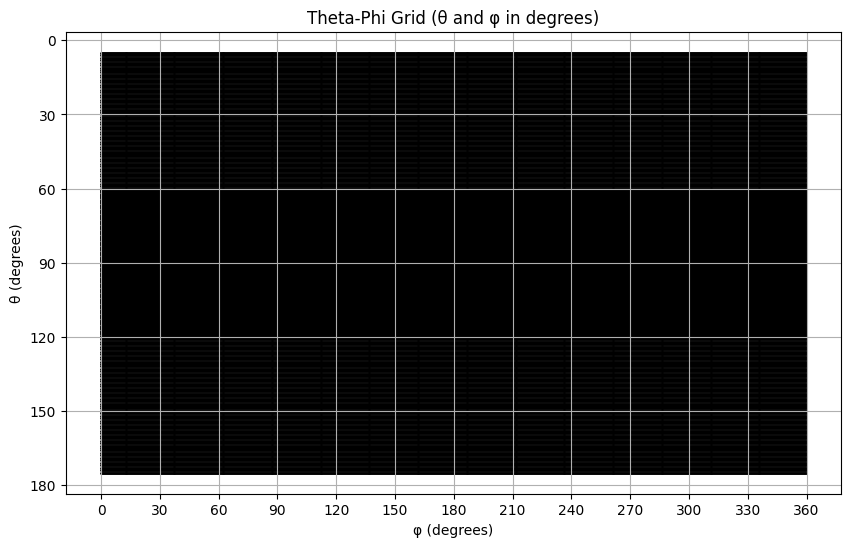

In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(Phi_deg1, Theta_deg1, s=1, color='black')
plt.xlabel("φ (degrees)")
plt.ylabel("θ (degrees)")
plt.gca().invert_yaxis()
plt.title("Theta-Phi Grid (θ and φ in degrees)")
plt.xticks(np.arange(0, 361, 30))
plt.yticks(np.arange(0, 181, 30))
plt.grid(True)
plt.show()

In [7]:
N_phi, N_theta

(720, 231)

In [8]:
Phi.shape, Theta.shape, T.shape

((231, 720), (231, 720), (720, 231))

In [9]:
dtheta_deg = np.zeros_like(theta_deg)

mid = len(theta_deg) // 2   # equator index

# northern half (including equator)
dtheta_deg[:mid+1] = np.diff(theta_deg[:mid+2])

# southern half: mirror
dtheta_deg[mid+1:] = dtheta_deg[:mid][::-1]

dtheta_rad = dtheta_deg * deg2rad


assert np.allclose(dtheta_rad, dtheta_rad[::-1]) 

In [10]:
print(T.shape)

(720, 231)


In [11]:
B0 = 1.3e-4

initial_profile = B0 * 0.5 * (3 * np.cos(theta)**2 - 1)

# Remove any tiny numerical monopole (ensures div B = 0 numerically)
#initial_profile -= np.sum(initial_profile * np.sin(theta)) / np.sum(np.sin(theta))

T[:, :] = initial_profile[None, :]

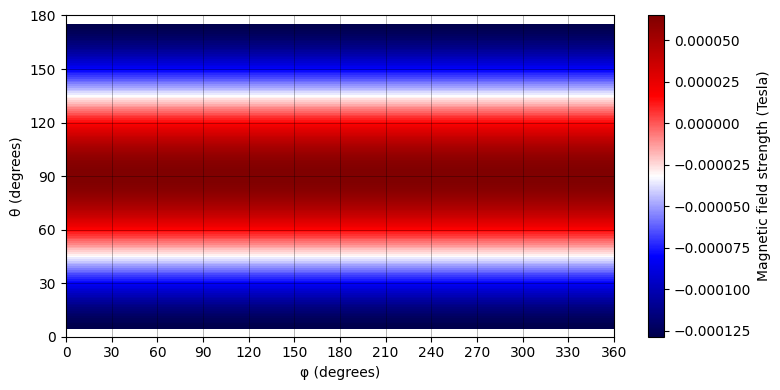

In [12]:
plt.figure(figsize=(8, 4))
plt.pcolormesh(Phi_deg1,Theta_deg1,-T.T,cmap="seismic",shading="nearest")
plt.colorbar(label="Magnetic field strength (Tesla)")
plt.xlabel("φ (degrees)")
plt.ylabel("θ (degrees)")
plt.ylim(theta_deg[0], theta_deg[-1])
xt = np.arange(0, 361, 30)
yt = np.arange(0, 181, 30)
plt.xticks(xt)
plt.yticks(yt)
for x in xt:
    plt.axvline(x, color="k", linewidth=0.5, alpha=0.4)

for y in yt:
    plt.axhline(y, color="k", linewidth=0.5, alpha=0.4)
plt.tight_layout()
plt.show()

In [13]:
omega = omega_max - (2.3 * (np.cos(theta))**2 - 1.62* (np.cos(theta))**4) * deg2rad

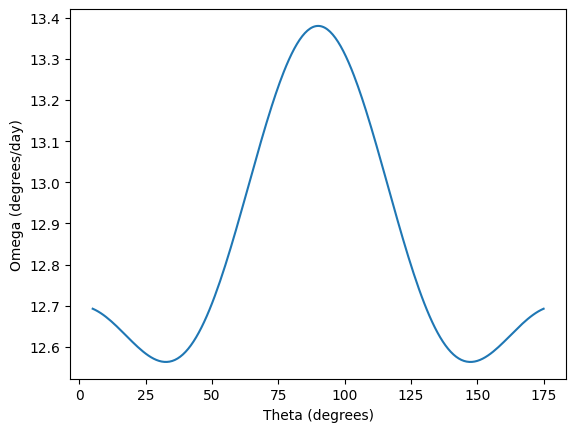

In [14]:
plt.plot(theta_deg, omega * rad2deg)
plt.xlabel("Theta (degrees)")
plt.ylabel(f"Omega (degrees/day)")
plt.show()

In [15]:
col = theta*rad2deg-90
v_mer = np.where(np.abs(col)<=75, v_mer_max * np.sin(np.pi * col / 75), 0)

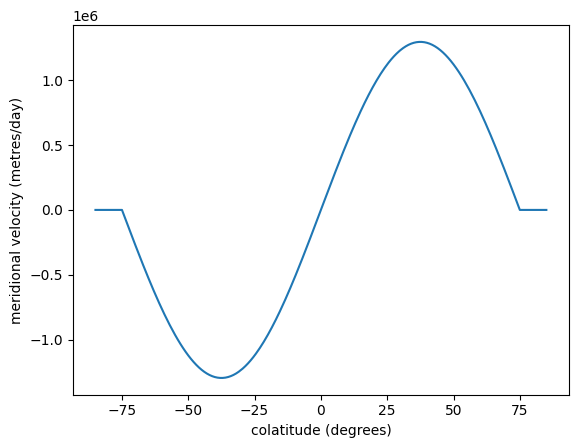

In [16]:
plt.plot(col, v_mer)
plt.xlabel("colatitude (degrees)")
plt.ylabel("meridional velocity (metres/day)")
plt.show()

In [17]:
cot = 1/np.tan(theta)
sin2 = (np.sin(theta))**2
senin = 1/(np.sin(theta))
cos = np.cos(theta).astype(np.float32)
sin = np.sin(theta).astype(np.float32)
all_values = np.zeros((N_save, N_phi, N_theta),dtype=np.float32)
T = T.astype(np.float32)
all_values[0, :, :] = T
T_new = np.zeros_like(T).astype(np.float32)
T_new.shape

(720, 231)

In [18]:
north_cap = theta_deg<= 30
south_cap = theta_deg>= 150

element_area = (R**2) * sin * dtheta_rad * dphi
dipole_weight = cos * element_area

flux_north = []
flux_south = []
flux_total = []
time_days = []
dipole_moment = []

In [19]:
#accum_bottom = np.zeros(N_phi)
#accum_top = np.zeros(N_phi)
save_idx = 0
all_values[save_idx, :, :]  = T
#all_values[save_idx, :, 0]  = accum_bottom
#all_values[save_idx, :, -1] = accum_top
save_idx += 1

In [20]:
C_phi_local = np.abs(omega) * dt / dphi
C_theta_local = np.abs(v_mer) * dt / (R * dtheta_rad)

print(f"Max C_phi = {np.max(C_phi_local):.4f}, Max C_theta = {np.max(C_theta_local):.4f}")

if np.max(C_phi_local) > 1.0 or np.max(C_theta_local) > 1.0:
    print("Warning: Local advection CFL > 1 — explicit scheme may become unstable.")


Max C_phi = 0.0268, Max C_theta = 0.0002


In [21]:
current_month = 0
next_bmr_index = 0

In [22]:
for n in range(1, N_steps + 1):
    t_days = n * dt
    month = int(t_days/30)

    if month > current_month:
        print(f"{month} month(s) start")
        current_month = month

    idx = next_bmr_index
    while idx < len(bmr) and not bmr_added[idx] and month >= bmr[idx, 0]:

        phase = bmr[idx, 0]
        lat_deg = bmr[idx, 1]
        tilt_deg = bmr[idx, 2]
        radius_Mm = bmr[idx, 3]
        lon_deg = bmr[idx, 4]
        flux = bmr[idx, 5]

        if month < phase:
            continue

        lat = lat_deg * deg2rad
        lon = lon_deg * deg2rad
        tilt = tilt_deg * deg2rad
        theta_c = np.pi/2.0 - lat

        R_cm = R * 100.0
        radius_cm = radius_Mm * 1e8

        ang_rad = radius_cm / R_cm # half angle of spot from centr
        sep_factor = 3.0
        d = sep_factor * ang_rad  # angular separation between spots

        dx = (d / 2.0) * np.cos(tilt)
        dy = (d / 2.0) * np.sin(tilt)
        dphi_off = dx / np.cos(lat)    # small angle correction for longitude
        dtheta_off = -dy
        sgn = 1 if lat > 0 else -1
        theta_lead  = theta_c + sgn * abs(dtheta_off)
        theta_trail = theta_c - sgn * abs(dtheta_off)

        phi_pos = lon + dphi_off
        phi_neg = lon - dphi_off

        if lat_deg > 0:      # Northern hemisphere
            leading_sign = +1
        else:                # Southern hemisphere
            leading_sign = -1

        flux_lead = leading_sign * flux
        flux_trail = -leading_sign * flux # assumed that the input flux is given for each spot(leading or following) 

        cap_area = 2.0 * np.pi * (R_cm**2) * (1.0 - np.cos(ang_rad)) #cm^2

        B0_lead = flux_lead / cap_area
        B0_trail = flux_trail / cap_area

        B0_lead_T = B0_lead * 1e-4
        B0_trail_T = B0_trail * 1e-4

        print("Inserting BMR idx=", idx, "phase=", phase, "month=", month)
        print(f" lat={lat_deg:.2f} deg, lon={lon_deg:.2f} deg, tilt={tilt_deg:.2f} deg")
        print(f" radius(Mm)={radius_Mm:.3f}, radius_cm={radius_cm:.3e}, ang_rad(deg)={(ang_rad*rad2deg):.4f}")
        print(f" flux(Mx)={flux:.3e}, cap_area(cm2)={cap_area:.3e}")
        print(f" B0_lead(T)={B0_lead_T:.3e}, B0_trail(T)={B0_trail_T:.3e}")

        cos_gamma_lead = (np.sin(Theta_grid) * np.sin(theta_lead) * np.cos(Phi_grid - phi_pos)
                         + np.cos(Theta_grid) * np.cos(theta_lead))
        #cos_gamma_lead = np.clip(cos_gamma_lead, -1.0, 1.0)
        #mask_lead = (cos_gamma_lead >= np.cos(ang_rad))
        #T[mask_lead] += B0_lead_T

        cos_gamma_trail = (np.sin(Theta_grid) * np.sin(theta_trail) * np.cos(Phi_grid - phi_neg) + np.cos(Theta_grid) * np.cos(theta_trail))
        #cos_gamma_trail = np.clip(cos_gamma_trail, -1.0, 1.0)
        #mask_trail = (cos_gamma_trail >= np.cos(ang_rad))
        #T[mask_trail] += B0_trail_T

        gamma_lead = np.arccos(cos_gamma_lead)
        gamma_trail = np.arccos(cos_gamma_trail)

        sigma = ang_rad/3 #assumed to have 1 percent of peak at gamma=alpha 

        B0_lead_T = flux_lead / (2.0 * np.pi * (R_cm**2) * sigma**2) * 1e-4 #after normalizing for flux 
        B0_trail_T = flux_trail / (2.0 * np.pi * (R_cm**2) * sigma**2) * 1e-4 #and small angle approximation

        T += B0_lead_T * np.exp(-0.5 * (gamma_lead / sigma)**2)
        T += B0_trail_T * np.exp(-0.5 * (gamma_trail / sigma)**2)        
        #nlead = np.count_nonzero(mask_lead)
        #ntrail = np.count_nonzero(mask_trail)
        #print(f" mask cells pos={nlead}, neg={ntrail}")

        bmr_added[idx] = True
        next_bmr_index += 1
        idx = next_bmr_index
    i_sl = slice(1, -1)
    j_sl = slice(1, -1)

    Tc   = T[i_sl, j_sl]                 
    T_ip = T[2:,  j_sl]                  
    T_im = T[:-2, j_sl]                 
    T_jp = T[i_sl, 2:]                   
    T_jm = T[i_sl, :-2]                  

    dth     = dtheta_rad[1:-1]         
    inv_dth = 1.0 / dth
    inv_dth2= inv_dth**2
    sin_i   = sin[1:-1]
    sin2_i  = sin2[1:-1]
    cos_i   = cos[1:-1]
    cot_i   = cot[1:-1]
    sin_c    = sin[1:-1]                   
    sin_ph   = sin[2:]                      
    sin_mh   = sin[:-2]                    
    omg_c    = omega[1:-1]                  
    v_ph     = 0.5*(v_mer[1:-1] + v_mer[2:])  
    v_mh     = 0.5*(v_mer[:-2]  + v_mer[1:-1]) 

    eps = 1e-1
    sin_i_safe  = np.maximum(sin_i,  eps)
    sin2_i_safe = np.maximum(sin2_i, eps**2)
    cot_i_safe = np.maximum(cot_i, eps)

    dT_dtheta_ph = (T_jp - Tc) / dth
    dT_dtheta_mh = (Tc - T_jm) / dth

    flux_ph = sin_ph * dT_dtheta_ph
    flux_mh = sin_mh * dT_dtheta_mh

    theta_diff = (flux_ph - flux_mh) / (sin_i * dth)
    d2T_dphi   = (T_ip - 2.0 * Tc + T_im) / (dphi**2)

    diffusion = (alpha / (R**2)) * dt * (theta_diff + (d2T_dphi / sin2_i))   #diffusion term

    div_phi = omg_c * (Tc - T_im) / dphi   #-omega(theta) * del(B)/del(phi)

    vph_pos = v_ph >= 0
    vmh_pos = v_mh >= 0

    T_up_ph = np.where(vph_pos, Tc, T_jp)  
    Fth_ph  = v_ph * T_up_ph * sin_ph        

    T_up_mh = np.where(vmh_pos, T_jm, Tc) 
    Fth_mh  = v_mh * T_up_mh * sin_mh

    div_theta = (Fth_ph - Fth_mh) / dth  
    div_theta = div_theta / (R * sin_c)   

    advection = -div_phi - div_theta

    tau = 5 * 365      
    decay = -Tc / tau  # add decay term to prevent polar flux increasing too much

    T_new[i_sl, j_sl] = Tc + diffusion + dt * advection + dt * decay

    if np.any(np.isnan(T_new)) or np.any(np.isinf(T_new)):
        print(f"Numerical instability at step {n}")
        print(f"Max value in T_new: {np.nanmax(T_new)}, Min value: {np.nanmin(T_new)}")
        bad_indices = np.argwhere(~np.isfinite(T_new))
        print(f"Non-finite entries at indices (i,j): {bad_indices[:10]}")
        break

    T_new[0,   1:-1] = T_new[-2, 1:-1]
    T_new[-1,  1:-1] = T_new[1,  1:-1]

    #accum_bottom += T_new[:, 1]
    #accum_top    += T_new[:, -2]
    T_new[1:-1, 0] = np.mean(T_new[1:-1, 1])
    T_new[1:-1, -1] = np.mean(T_new[1:-1, -2])
    T = T_new.copy()
    if (n % save) == 0:
        all_values[save_idx, :, :]  = T
        #all_values[save_idx, :, 0]  = accum_bottom
        #all_values[save_idx, :, -1] = accum_top
        save_idx += 1
        flux_n = np.sum(T[:,north_cap] * element_area[north_cap][None,:])
        flux_s = np.sum(T[:,south_cap] * element_area[south_cap][None,:])
        flux_t = np.sum(T[:,:] * element_area[None,:])
        dip = 1.5 * np.sum(T * dipole_weight[None,:])
        
        dipole_moment.append(dip)
        flux_north.append(flux_n)
        flux_south.append(flux_s)
        flux_total.append(flux_t)
        time_days.append(t_days)

1 month(s) start
Inserting BMR idx= 0 phase= 1.0 month= 1
 lat=22.00 deg, lon=63.00 deg, tilt=-4.31 deg
 radius(Mm)=74.943, radius_cm=7.494e+09, ang_rad(deg)=6.1694
 flux(Mx)=2.704e+20, cap_area(cm2)=1.763e+20
 B0_lead(T)=1.534e-04, B0_trail(T)=-1.534e-04
Inserting BMR idx= 1 phase= 1.0 month= 1
 lat=-22.00 deg, lon=63.00 deg, tilt=4.31 deg
 radius(Mm)=74.943, radius_cm=7.494e+09, ang_rad(deg)=6.1694
 flux(Mx)=-2.704e+20, cap_area(cm2)=1.763e+20
 B0_lead(T)=1.534e-04, B0_trail(T)=-1.534e-04
2 month(s) start
Inserting BMR idx= 2 phase= 2.0 month= 2
 lat=23.00 deg, lon=155.00 deg, tilt=4.41 deg
 radius(Mm)=64.525, radius_cm=6.452e+09, ang_rad(deg)=5.3118
 flux(Mx)=2.058e+20, cap_area(cm2)=1.307e+20
 B0_lead(T)=1.574e-04, B0_trail(T)=-1.574e-04
Inserting BMR idx= 3 phase= 2.0 month= 2
 lat=-23.00 deg, lon=155.00 deg, tilt=-4.41 deg
 radius(Mm)=64.525, radius_cm=6.452e+09, ang_rad(deg)=5.3118
 flux(Mx)=-2.058e+20, cap_area(cm2)=1.307e+20
 B0_lead(T)=1.574e-04, B0_trail(T)=-1.574e-04
3 mont

In [23]:
import matplotlib as mpl
mpl.rcParams['animation.embed_limit'] = 50

In [24]:
all_values = np.transpose(all_values,(0,2,1))

In [25]:
from matplotlib.animation import FuncAnimation
fig, ax = plt.subplots()

phi_edges = np.linspace(0, 360, all_values.shape[2])
lat_edges = np.linspace(90, -90, all_values.shape[1])

cax = ax.pcolormesh(
    phi_edges,
    lat_edges,
    all_values[0],
    shading='nearest',
    cmap='seismic',
    vmin=-1e-3,
    vmax=1e-3
)

fig.colorbar(cax, label='Magnetic field strength (Tesla)')
ax.set_title('2D Magnetic Field')
ax.set_xlabel('φ (degrees)')
ax.set_ylabel('Latitude (degrees)')
ax.set_aspect('equal', adjustable='box')
ax.set_xticks(np.arange(0, 361, 30))
ax.set_yticks(np.arange(90, -91, -15))
ax.grid(True)

def animate(frame):
    cax.set_array(all_values[frame].ravel())
    ax.set_title(f'Magnetic field of quadrupolar star at t = {frame*dt*save/365:.2f} years')
    return [cax]

ani = FuncAnimation(
    fig,
    animate,
    frames=range(0, all_values.shape[0], 100),
    interval=1000,
    blit=True,
    repeat=False
)

plt.close(fig)
from IPython.display import HTML
HTML(ani.to_jshtml())


In [26]:
from matplotlib.animation import PillowWriter
writer = PillowWriter(fps=2)
ani.save('sunspot_evolution_11_years_symmetric31mar_quad.gif', writer=writer)

In [27]:
all_values.shape

(2008, 231, 720)

In [28]:
# import h5py
# import numpy as np

# with h5py.File("all_values_sym14jan.h5", "w") as f:
#     dset = f.create_dataset(
#         "all_values",
#         shape=all_values.shape,
#         dtype=np.float32,
#         chunks=(1,214,720),
#         compression=None
#     )

#     for t in range(all_values.shape[0]):
#         dset[t] = all_values[t]
#         if t % 100 == 0:
#             f.flush()
#             print("Written", t)


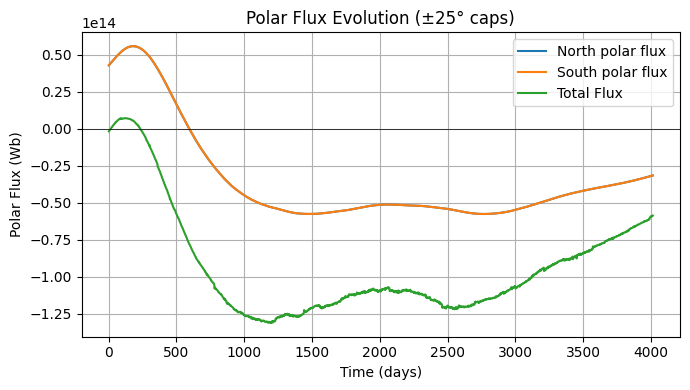

In [29]:
plt.figure(figsize=(7,4))

plt.plot(time_days, flux_north, label="North polar flux")
plt.plot(time_days, flux_south, label="South polar flux")
plt.plot(time_days, flux_total, label="Total Flux")
plt.axhline(0.0, color='k', lw=0.5)
plt.xlabel("Time (days)")
plt.ylabel("Polar Flux (Wb)")
plt.title("Polar Flux Evolution (±25° caps)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("polar_flux_evolution_sym31mar_33_deg_poles_cos2_5_yr_decay_flux_cons_quad.png", dpi=300)
plt.show()

In [30]:
# time_months = df.iloc[:, 0].values
# latitude    = df.iloc[:, 1].values
# flux        = df.iloc[:, 5].values

# flux_norm = flux / np.max(flux)
# sizes = 50 + 300 * flux_norm

# plt.scatter(time_months, latitude, s=sizes, alpha=0.05, edgecolors='black')
# plt.xlabel("Time (months)")
# plt.ylabel("Latitude (degrees)")
# plt.title("Sunspot Emergence")
# plt.grid(True)
# plt.savefig("sunspot_emergence_sym2.png")
# plt.grid()

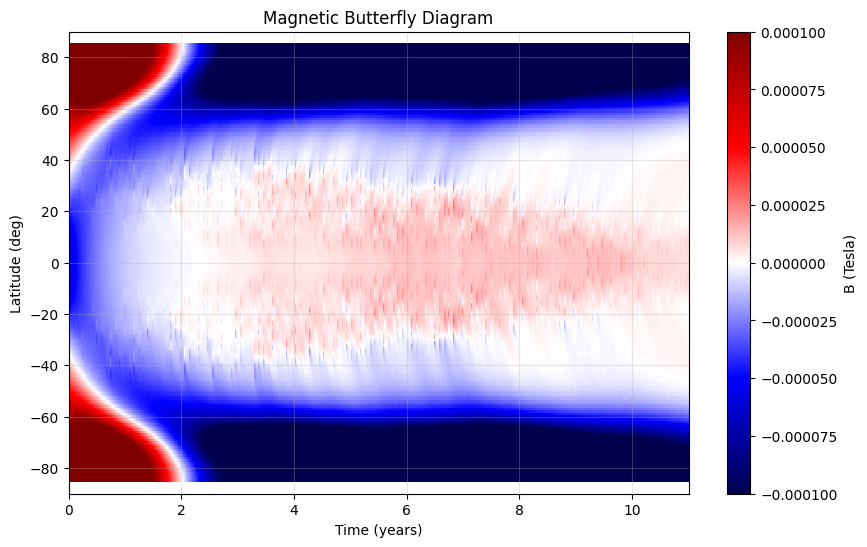

In [31]:
B_butterfly = np.mean(all_values, axis=2)
lat_deg = 90.0 - theta_deg
time_years = np.arange(all_values.shape[0]) * save * dt / 365.0

plt.figure(figsize=(10,6))
plt.pcolormesh(
    time_years,
    lat_deg,
    B_butterfly.T,
    shading='nearest',
    cmap='seismic',
    vmin=-1e-4,
    vmax=1e-4
)
plt.colorbar(label='B (Tesla)')
plt.xlabel('Time (years)')
plt.ylabel('Latitude (deg)')
plt.title('Magnetic Butterfly Diagram')
plt.ylim(-90, 90)
plt.grid(alpha=0.3)
plt.savefig("butterfly_diagram_sym31mar_33_deg_poles_cos2_5_yr_decay_quad.png", dpi=300, bbox_inches="tight")
plt.show()


In [32]:
#with h5py.File("all_values.h5", "r") as f:
    #all_values = f["all_values"]

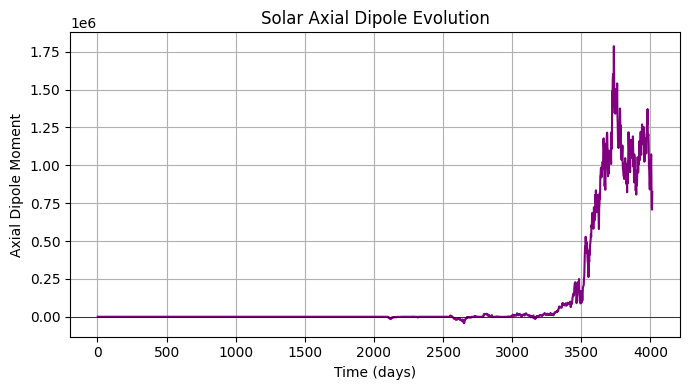

In [33]:
plt.figure(figsize=(7,4))

plt.plot(time_days, dipole_moment, color="purple")
plt.axhline(0,color="k",lw=0.5)

plt.xlabel("Time (days)")
plt.ylabel("Axial Dipole Moment")
plt.title("Solar Axial Dipole Evolution")

plt.grid()
plt.tight_layout()
plt.savefig("dipole_moment31mar_33_deg_poles_cos2_5_yr_decay_quad.png",dpi=300)
plt.show()